In [9]:
from model_ranking.utils import load_h5, get_unique_colourmap
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
pred1_path = "/g/kreshuk/talks/model_ranking/scripts/test_scripts/sweep2/BBBC039_to_BBBC039_gap/feature_perturbation_consistency/test/BC_IN_model2/norm_50_980/DO_a02/predictions/IXMtest_A15_s5_w1825174D4-ED30-490C-9635-6196417D6C9D_predictions.h5"
pred2_path = "/g/kreshuk/talks/domain_gap/experiments/Instance_segmentation/BBBC039_to_BBBC039_gap/feature_perturbation_consistency/run2/BC_IN_model2/norm_5_98/DO_a02/predictions/IXMtest_A15_s5_w1825174D4-ED30-490C-9635-6196417D6C9D_predictions.h5"
pred1 = load_h5(pred1_path, "segmentation")
pred2 = load_h5(pred2_path, "segmentation")
pred1_none_path = "/g/kreshuk/talks/model_ranking/scripts/test_scripts/sweep2/BBBC039_to_BBBC039_gap/feature_perturbation_consistency/test/BC_IN_model2/norm_50_980/none/predictions/IXMtest_A15_s5_w1825174D4-ED30-490C-9635-6196417D6C9D_predictions.h5"
pred2_none_path = "/g/kreshuk/talks/domain_gap/experiments/Instance_segmentation/BBBC039_to_BBBC039_gap/feature_perturbation_consistency/run2/BC_IN_model2/norm_5_98/none/predictions/IXMtest_A15_s5_w1825174D4-ED30-490C-9635-6196417D6C9D_predictions.h5"
pred1_none = load_h5(pred1_none_path, "segmentation")
pred2_none = load_h5(pred2_none_path, "segmentation")


In [3]:
pred1_ARE = load_h5(pred1_path, "AdaRandError")
pred2_ARE = load_h5(pred2_path, "ARE_bckg0_b1_th00")

In [4]:
np.all(np.equal(pred1, pred2))

True

In [5]:
np.all(np.equal(pred1_none, pred2_none))

True

In [6]:
print(pred1_ARE)

[0.0420653  0.9739378  0.94244903]


In [7]:
print(pred2_ARE)

0.007541656220114157


In [8]:
pred1_ARE[0]

0.042065304

In [13]:
pred_dir_path = Path("/g/kreshuk/talks/model_ranking/scripts/test_scripts/DO_a02/predictions")
#pred2_dir_path = Path("/g/kreshuk/talks/domain_gap/experiments/Instance_segmentation/BBBC039_to_BBBC039_gap/feature_perturbation_consistency/run2/BC_IN_model2/norm_5_98/DO_a02/predictions")

for pred_file in list(pred_dir_path.glob("*.h5")):
    #assert np.all(np.equal(pred1, pred2)), f"Mismatch in {pred_file.name}"
    eval_score1 = load_h5(pred_file, "ARE_eval_test1")
    consis_score1 = load_h5(pred_file, "ARE_consis_test1")
    #assert np.all(np.equal(eval_score1, eval_score2)), f"Mismatch in {pred_file.name}"
    eval_score2 = load_h5(pred_file, "ARE_bckg0_b1")
    consis_score2 = load_h5(pred_file, "ARE_bckg0_b1_th00")
    print(f"Consistency scores new: {consis_score1}")
    print(f"Consistency score old: {consis_score2}")
    print(f"ARE Eval score new: {eval_score1}")
    print(f"ARE Eval score old: {eval_score2}")
    print("----------------------")

Consistency scores new: [0.00754166 0.99674326 0.9882101 ]
Consistency score old: 0.007541656220114157
ARE Eval score new: [0.0420653  0.9739378  0.94244903]
ARE Eval score old: [0.0420653  0.9739378  0.94244903]
----------------------
Consistency scores new: [0. 1. 1.]
Consistency score old: 0.0
ARE Eval score new: [0.04584477 0.9930763  0.9181699 ]
ARE Eval score old: [0.04584477 0.9930763  0.9181699 ]
----------------------
Consistency scores new: [0.01090757 0.97842026 1.        ]
Consistency score old: 0.010907567280730834
ARE Eval score new: [0.00629568 0.9913496  0.99607027]
ARE Eval score old: [0.00629568 0.9913496  0.99607027]
----------------------
Consistency scores new: [0. 1. 1.]
Consistency score old: 0.0
ARE Eval score new: [0.00481593 0.9925117  0.99787086]
ARE Eval score old: [0.00481593 0.9925117  0.99787086]
----------------------
Consistency scores new: [0.01029819 0.9857357  0.9936999 ]
Consistency score old: 0.010298189965244342
ARE Eval score new: [0.12817658 0.9

In [4]:
file_paths1 = list(pred1_dir_path.glob("*.h5"))
pred1 = load_h5(file_paths1[1], "segmentation")
pred2 = load_h5(pred2_dir_path / file_paths1[1].name, "segmentation")


In [6]:
pred1

array([[ 1,  1,  1, ...,  0,  0,  0],
       [ 1,  1,  1, ...,  0,  0,  0],
       [ 1,  1,  1, ...,  0,  0,  0],
       ...,
       [45,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]])

In [7]:
pred2

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

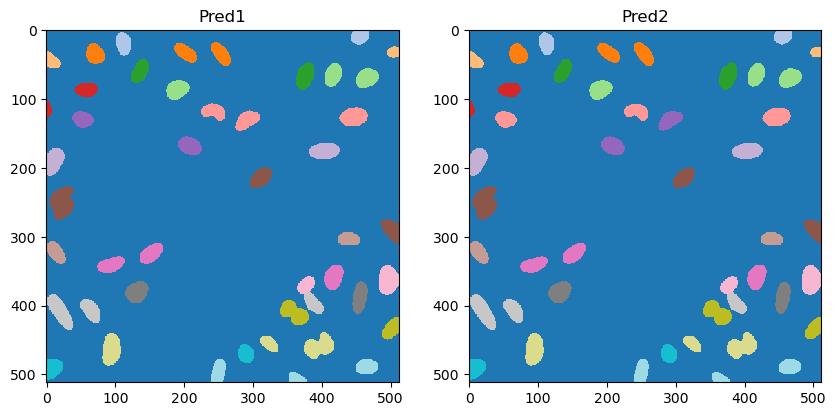

In [10]:
import matplotlib.pyplot as plt

_, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].set_title("Pred1")
axs[0].imshow(pred1, cmap="tab20", interpolation="nearest")
axs[1].set_title("Pred2")
axs[1].imshow(pred2, cmap="tab20", interpolation="nearest")
plt.show()